
# Diffusion MRI Simulators: Hands-on Tutorial

Walk through DMRI's simulator API: build acquisition schemes, simulate single-compartment models (Ball/Stick), and mix them into multi-compartment signals.


In [ ]:
%reload_ext autoreload
%autoreload 2

In [ ]:
import jax
import jax.numpy as jnp
import numpy as np

from dmri.simulators import Ball, Stick, Zeppelin, Sphere, Cylinder, MultiCompartment
from dmri.simulators.acquisition_scheme import acquisition_scheme


## 1. Build an acquisition scheme

`acquisition_scheme` bundles **b-values** (diffusion weighting) and **b-vectors** (gradient directions). We sample 100 directions on a unit sphere and linearly spaced b-values up to 3000 s/mm².


In [ ]:
bvals = jnp.linspace(0, 3000, 100)
bvecs = jax.random.normal(jax.random.key(0), (100, 3))
bvecs = bvecs / jnp.linalg.norm(bvecs, axis=-1, keepdims=True)

acq = acquisition_scheme(bvals, bvecs)
acq


## 2. Single-compartment examples

### Ball: isotropic diffusion
The Ball model represents free water with scalar diffusivity \(\lambda\).


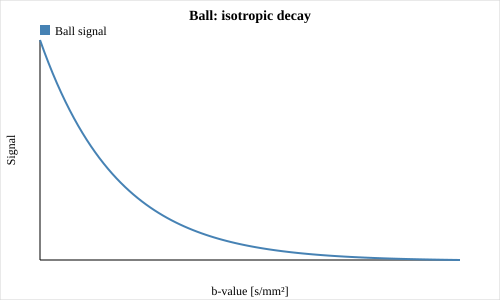

In [ ]:
lam = 0.0018  # mm^2/s
ball = Ball(lam)
ball_signal = ball.signal(acq)
ball_signal


### Stick: orientation dependence
The Stick has zero radius and attenuates based on the projection of the gradient onto its orientation \(oldsymbol{\mu}\).


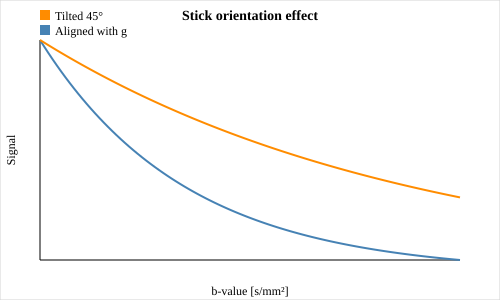

In [ ]:
stick_aligned = Stick(jnp.array([0.0, 0.0]), lam_par=0.0015)
stick_tilted = Stick(jnp.array([jnp.pi/4, 0.0]), lam_par=0.0015)

signal_aligned = stick_aligned.signal(acq)
signal_tilted = stick_tilted.signal(acq)
signal_aligned, signal_tilted


## 3. Multi-compartment mixture

Combine compartments by subclassing `MultiCompartment`. Here we mix Ball + Stick with equal fractions to illustrate how fractions change the decay.

In addition to the compartments that emulate the signal we can additionally add `NoiseCompoartments`


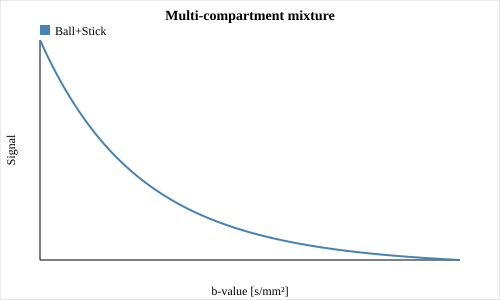

In [ ]:
class BallStick(MultiCompartment):
    model_types = [Ball, Stick]
    noise_types = []
    fraction_prior = jnp.ones(2)

theta = jax.random.normal(jax.random.key(123), (BallStick.theta_dim,))
model = BallStick.from_theta(theta)
signal_mix = model.signal(acq)
signal_mix


## 4. Next steps
- Swap in `Sphere` or `Cylinder` to explore restricted diffusion.
- Add noise compartments (e.g., `BoundedGaussianNoise`) when simulating magnitude data.
- Use `model_mask` in `MultiCompartment.from_theta` to toggle components without changing the parameter layout.

For a deeper API tour, see `docs/guides/simulators.md`.
